In [15]:
import pandas as pd
import yfinance as yfin
import matplotlib.pyplot as plt
import datetime as dt
import numpy as np
from scipy import stats

In [16]:
NiftyTicker = ['^NSEI']
RelianceTicker = ['RELIANCE.NS']

# Indicate the start and end dates
start = dt.datetime.now().replace(year=dt.datetime.now().year - 5)
end = dt.datetime.now()

nifty = yfin.download(NiftyTicker, start = start, end = end)
reliance = yfin.download(RelianceTicker, start, end)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [17]:
nifty['Returns'] = nifty['Close'].squeeze().pct_change(1) * 100
reliance['Returns'] = reliance['Close'].squeeze().pct_change(1) * 100

riskFreeDailyReturns = 6.5/252   # 6.5% annual, expressed as daily percent

# Build the joint frame FIRST, then drop NaNs, so both series are
# guaranteed to share the same trading days (any mismatched day drops cleanly).
returns = pd.DataFrame({
    'niftyAdjusted':    nifty['Returns'],
    'relianceAdjusted': reliance['Returns'],
}).dropna()

# Subtract the (constant) daily risk-free rate to get excess returns.
returns = returns - riskFreeDailyReturns

print(f"Observations used: {len(returns)}")
returns

Observations used: 1233


C:\Users\kanak\AppData\Local\Temp\ipykernel_4404\4150953966.py:2: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  reliance['Returns'] = reliance['Close'].squeeze().pct_change(1) * 100


,niftyAdjusted,relianceAdjusted
Date,,
2021-08-26,-0.012268,1.238616
2021-08-27,0.384733,-0.162532
2021-08-30,1.326190,1.897968
2021-08-31,1.162251,-0.558767
2021-09-01,-0.352367,0.370546
...,...,...
2026-08-17,-0.347347,0.432222
2026-08-18,-0.572368,0.430133
2026-08-19,-0.342912,-0.857866


In [18]:
slope, intercept, r_value, p_value, std_err = stats.linregress(returns['niftyAdjusted'], returns['relianceAdjusted'])

In [19]:
print(f"Beta (slope):        {slope:.4f}")
print(f"Alpha (intercept):   {intercept:.6f}  (daily %)")
print(f"Alpha annualized:    {intercept*252:.4f}  (% per year, approx)")
print(f"R-squared:           {r_value**2:.4f}")
print(f"Correlation r:       {r_value:.4f}")
print(f"P-value (beta != 0): {p_value:.2e}")

Beta (slope):        1.1085
Alpha (intercept):   -0.002910  (daily %)
Alpha annualized:    -0.7332  (% per year, approx)
R-squared:           0.4688
Correlation r:       0.6847
P-value (beta != 0): 2.65e-171


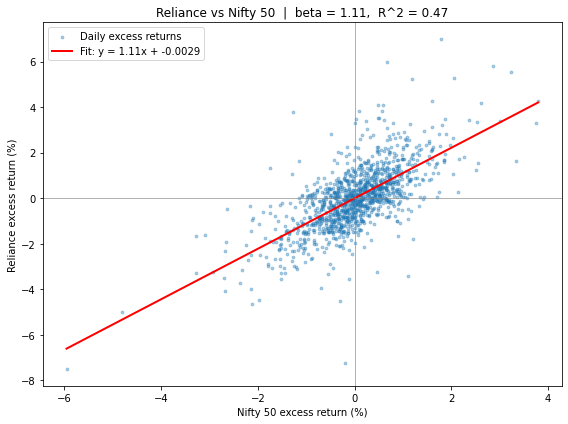

In [20]:
# Scatter of excess returns with the fitted CAPM characteristic line
x = returns['niftyAdjusted']
y = returns['relianceAdjusted']

plt.figure(figsize=(8, 6))
plt.scatter(x, y, s=8, alpha=0.35, label='Daily excess returns')

x_line = np.linspace(x.min(), x.max(), 100)
plt.plot(x_line, intercept + slope * x_line, color='red', linewidth=2,
         label=f'Fit: y = {slope:.2f}x + {intercept:.4f}')

plt.axhline(0, color='grey', linewidth=0.6)
plt.axvline(0, color='grey', linewidth=0.6)
plt.title(f'Reliance vs Nifty 50  |  beta = {slope:.2f},  R^2 = {r_value**2:.2f}')
plt.xlabel('Nifty 50 excess return (%)')
plt.ylabel('Reliance excess return (%)')
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
# Is beta statistically different from 1? (i.e. is Reliance really riskier
# than the market, or is beta ~ 1 within noise?)
# linregress gives std_err of the slope, so we t-test (beta - 1)/std_err.

n = len(returns)
df = n - 2                      # degrees of freedom for a simple regression
t_stat = (slope - 1) / std_err
p_two_sided = 2 * stats.t.sf(abs(t_stat), df)

# 95% confidence interval for beta
t_crit = stats.t.ppf(0.975, df)
ci_low, ci_high = slope - t_crit * std_err, slope + t_crit * std_err

print(f"Beta:                 {slope:.4f}")
print(f"Std error of beta:    {std_err:.4f}")
print(f"95% CI for beta:      [{ci_low:.4f}, {ci_high:.4f}]")
print(f"t-stat (beta = 1):    {t_stat:.3f}")
print(f"p-value (beta != 1):  {p_two_sided:.4f}")
print()
if p_two_sided < 0.05:
    print("=> Beta is significantly different from 1 at the 5% level.")
else:
    print("=> Cannot reject beta = 1: statistically indistinguishable from the market.")

Beta:                 1.1085
Std error of beta:    0.0336
95% CI for beta:      [1.0425, 1.1745]
t-stat (beta = 1):    3.227
p-value (beta != 1):  0.0013

=> Beta is significantly different from 1 at the 5% level.
